In [1]:
import os, requests
from tqdm import tqdm
import json

os.makedirs("coco/images", exist_ok=True)

with open("coco/annotations/instances_train2017.json") as f:
    data = json.load(f)

cow_cat_id = [c["id"] for c in data["categories"] if c["name"] == "cow"][0]

cow_imgs = set([ann["image_id"] for ann in data["annotations"] if ann["category_id"] == cow_cat_id])
cow_imgs = list(cow_imgs)[:100]

id_to_filename = {img["id"]: img["file_name"] for img in data["images"]}

for img_id in tqdm(cow_imgs):
    fname = id_to_filename[img_id]
    url = f"http://images.cocodataset.org/train2017/{fname}"
    out_path = f"coco/images/{fname}"
    if not os.path.exists(out_path):
        r = requests.get(url)
        with open(out_path, "wb") as f:
            f.write(r.content)


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [03:19<00:00,  1.99s/it]


In [7]:
import torch
import torch.nn as nn

S, B, C = 7, 2, 1

class YOLOv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 192, 3, 1, 1), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(192, 128, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(128, 256, 3, 1, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 256, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, 3, 1, 1), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(512, 1024, 3, 1, 1), nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool2d((S, S))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096), nn.LeakyReLU(0.1),
            nn.Linear(4096, S * S * (C + B * 5))
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x.view(-1, S, S, C + B * 5)


In [9]:
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
])

class CowCocoDataset(Dataset):
    def __init__(self, image_dir, image_ids, coco_data, transform=None):
        self.image_dir = image_dir
        self.image_ids = image_ids
        self.transform = transform
        self.annotations = coco_data["annotations"]
        self.image_map = {img["id"]: img["file_name"] for img in coco_data["images"]}
        self.cow_anns = {i: [] for i in image_ids}
        for ann in self.annotations:
            if ann["category_id"] == cow_cat_id and ann["image_id"] in image_ids:
                self.cow_anns[ann["image_id"]].append(ann)

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        fname = self.image_map[img_id]
        img_path = os.path.join(self.image_dir, fname)
        image = Image.open(img_path).convert("RGB")

        w, h = image.size
        label = torch.zeros((S, S, C + B * 5))

        for ann in self.cow_anns[img_id]:
            x, y, bw, bh = ann['bbox']
            cx = (x + bw / 2) / w
            cy = (y + bh / 2) / h
            bw /= w
            bh /= h

            i, j = int(cx * S), int(cy * S)
            label[j, i, 0] = 1  # presence
            label[j, i, 1:5] = torch.tensor([cx, cy, bw, bh])  # bbox
            label[j, i, 5:9] = torch.tensor([cx, cy, bw, bh])  # second box
            label[j, i, 9] = 1  # class = cow (only one class)

        if self.transform:
            image = self.transform(image)

        return image, label


In [10]:
dataset = CowCocoDataset(
    image_dir="coco/images",
    image_ids=cow_imgs,
    coco_data=data,
    transform=transform
)

loader = DataLoader(dataset, batch_size=4, shuffle=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using", DEVICE)


Using cpu


In [11]:
def yolo_loss(preds, targets):
    loss_fn = nn.MSELoss()
    obj_loss = loss_fn(preds[..., 0], targets[..., 0])
    box_loss = loss_fn(preds[..., 1:5], targets[..., 1:5])
    class_loss = loss_fn(preds[..., 9:], targets[..., 9:])
    return obj_loss + box_loss + class_loss


In [12]:
model = YOLOv1().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

for epoch in range(5):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs)
        loss = yolo_loss(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")


Epoch 1 | Loss: 0.1078
Epoch 2 | Loss: 0.1021
Epoch 3 | Loss: 0.1008
Epoch 4 | Loss: 0.1009
Epoch 5 | Loss: 0.1007


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_preds(img, pred_tensor, threshold=0.4):
    img = img.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1)
    ax.imshow(img)
    for i in range(S):
        for j in range(S):
            cell = pred_tensor[0, j, i]
            conf = cell[0]
            if conf > threshold:
                bx, by, bw, bh = cell[1:5]
                x = (i + bx) * (img.shape[1] / S)
                y = (j + by) * (img.shape[0] / S)
                w = bw * img.shape[1]
                h = bh * img.shape[0]
                rect = patches.Rectangle((x - w/2, y - h/2), w, h, linewidth=2, edgecolor='r', facecolor='none')
                ax.add_patch(rect)
    plt.show()


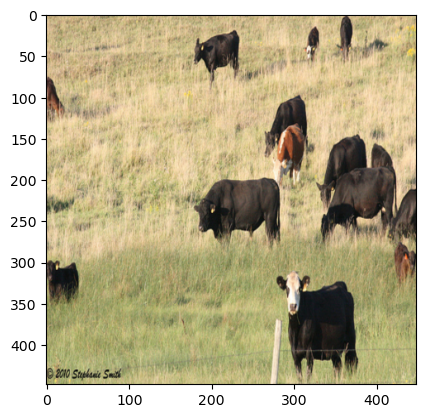

In [15]:
model.eval()
img, _ = dataset[0]
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(DEVICE))
show_preds(img, pred.cpu())
